<a href="https://colab.research.google.com/github/Emalte1/SIMULACION-1./blob/main/GENERACION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CALCULO DE VARIABALES DE ENTRADA

--- PASO 1: PARÁMETROS DE CAPTACIÓN ---
Seleccione la variable a calcular: 1:Caudal(Q) | 2:Longitud(L) | 3:Carga(H)
Opción: 3
Ingrese Caudal de diseño Q (m3/s): 1.8
Ingrese Longitud de cresta L (m): 7

--- PASO 2: ESPECIFICACIONES DE LA REJILLA ---
Ingrese el ancho de apertura entre barras 'a' (m) [Ej: 0.02]: 0.09
Ingrese el ancho de la barra 'b' (m) [Ej: 0.0095]: 0.02

--- PASO 3: BALANCE DE ENTREGA ---
Diámetro del tubo de salida ecológica (pulgadas): 10


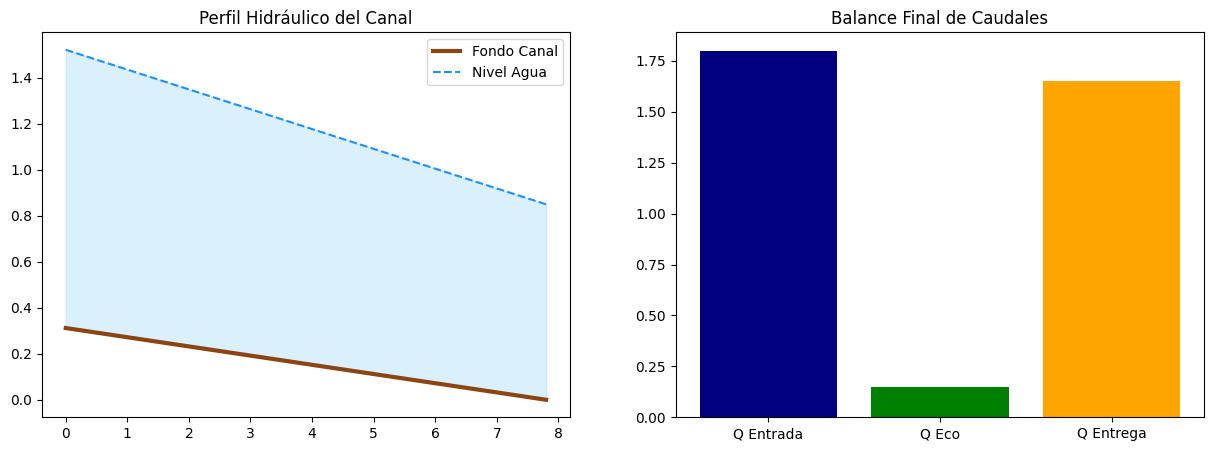


RESULTADO TÉCNICO                   | VALOR     
-------------------------------------------------------
Caudal de Diseño (Q)                | 1.8 m3/s
Ancho Apertura Rejilla (a)          | 0.09 m
Ancho Barra Rejilla (b)             | 0.02 m
Área Neta de Rejilla (Aneta)        | 4.18 m2
Velocidad de Paso (Vb)              | 0.48 m/s
Velocidad de Salida (Vc)            | 2.9 m/s
Caudal Ecológico (Q_eco)            | 0.147 m3/s
Caudal de Entrega Final (Q_Te)      | 1.653 m3/s


In [ ]:
import math
import matplotlib.pyplot as plt

# ==========================================================
# 1. ENTRADA DE DATOS DINÁMICA (ECUACIÓN DE FRANCIS Y REJILLA)
# ==========================================================
print("--- PASO 1: PARÁMETROS DE CAPTACIÓN ---")
print("Seleccione la variable a calcular: 1:Caudal(Q) | 2:Longitud(L) | 3:Carga(H)")
opcion = input("Opción: ")

if opcion == "1":
    L = float(input("Ingrese Longitud de cresta L (m): "))
    H = float(input("Ingrese Carga sobre vertedero H (m): "))
    Q_diseno = round(1.84 * L * math.pow(H, 1.5), 2)
elif opcion == "2":
    Q_diseno = float(input("Ingrese Caudal de diseño Q (m3/s): "))
    H = float(input("Ingrese Carga sobre vertedero H (m): "))
    L = round(Q_diseno / (1.84 * math.pow(H, 1.5)), 2)
elif opcion == "3":
    Q_diseno = float(input("Ingrese Caudal de diseño Q (m3/s): "))
    L = float(input("Ingrese Longitud de cresta L (m): "))
    H = round(math.pow(Q_diseno / (1.84 * L), 2/3), 2)
else:
    print("Opción no válida."); exit()

print("\n--- PASO 2: ESPECIFICACIONES DE LA REJILLA ---")
a = float(input("Ingrese el ancho de apertura entre barras 'a' (m) [Ej: 0.02]: "))
b = float(input("Ingrese el ancho de la barra 'b' (m) [Ej: 0.0095]: "))

# ==========================================================
# 2. PARÁMETROS FIJOS Y CÁLCULOS DE REJILLA
# ==========================================================
g, i, Lc, BL = 9.81, 0.04, 7.8, 0.15

# Velocidad del río y alcances
Vr = round(Q_diseno / (L * H), 2)
Xs = round((0.36 * math.pow(Vr, 2/3)) + (0.60 * math.pow(H, 4/7)), 2)
B = round(Xs + 0.10, 2)

# Área Neta utilizando los nuevos valores de a y b
Aneta = round((a / (a + b)) * B * L, 2)
N = round(Aneta / (a * B), 2)
Vb = round(Q_diseno / (0.9 * Aneta), 2)

# ==========================================================
# 3. CANAL DE ADUCCIÓN Y VELOCIDAD DE SALIDA
# ==========================================================
he = round(math.pow((math.pow(Q_diseno, 2)) / (g * math.pow(B, 2)), 1/3), 2)
t1 = 2 * math.pow(he, 2)
t2 = math.pow(he - (i * Lc / 3), 2)
h0 = round(math.pow(t1 + t2, 0.5) - (2/3 * i * Lc), 2)
Vc = round(Q_diseno / (he * B), 2)

# ==========================================================
# 4. BALANCE DE ENTREGA Y CAUDAL ECOLÓGICO
# ==========================================================
print("\n--- PASO 3: BALANCE DE ENTREGA ---")
diam_pulg = float(input("Diámetro del tubo de salida ecológica (pulgadas): "))
area_tubo = round(math.pi * math.pow((diam_pulg * 0.0254) / 2, 2), 4)

Q_eco = round(area_tubo * Vc, 4)
Q_Te = round(Q_diseno - Q_eco, 4)

H0_wall = round(h0 + BL, 2)
He_wall = round(H0_wall + (i * Lc), 2)

# ==========================================================
# 5. REPORTE FINAL Y GRÁFICOS
# ==========================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Perfil del Canal
x = [0, Lc]
y_fondo = [i * Lc, 0]
y_agua = [(i * Lc) + h0, he]
ax1.plot(x, y_fondo, color='saddlebrown', lw=3, label='Fondo Canal')
ax1.plot(x, y_agua, color='dodgerblue', ls='--', label='Nivel Agua')
ax1.fill_between(x, y_fondo, y_agua, color='lightskyblue', alpha=0.3)
ax1.set_title("Perfil Hidráulico del Canal")
ax1.legend()

# Balance de Caudales
ax2.bar(['Q Entrada', 'Q Eco', 'Q Entrega'], [Q_diseno, Q_eco, Q_Te], color=['navy', 'green', 'orange'])
ax2.set_title("Balance Final de Caudales")

plt.show()

print("\n" + "="*55)
print(f"{'RESULTADO TÉCNICO':<35} | {'VALOR':<10}")
print("-" * 55)
print(f"{'Caudal de Diseño (Q)':<35} | {Q_diseno} m3/s")
print(f"{'Ancho Apertura Rejilla (a)':<35} | {a} m")
print(f"{'Ancho Barra Rejilla (b)':<35} | {b} m")
print(f"{'Área Neta de Rejilla (Aneta)':<35} | {Aneta} m2")
print(f"{'Velocidad de Paso (Vb)':<35} | {Vb} m/s")
print(f"{'Velocidad de Salida (Vc)':<35} | {Vc} m/s")
print(f"{'Caudal Ecológico (Q_eco)':<35} | {Q_eco} m3/s")
print(f"{'Caudal de Entrega Final (Q_Te)':<35} | {Q_Te} m3/s")
print("="*55)

# Calculo inverso de caludal optimo desde el caudal de entrega

--- SISTEMA DE DISEÑO Y OPTIMIZACIÓN DE BOCATOMAS ---
1. Calcular Q (Tengo L y H)
2. Calcular L (Tengo Q y H)
3. Calcular H (Tengo Q y L)
4. OPTIMIZACIÓN INVERSA: Definir Q de Entrega deseado
Seleccione una opción: 4
Ingrese el Caudal de Entrega deseado en el tanque (m3/s): 1.8
Diámetro del tubo de salida ecológica (pulgadas): 5

--- Buscando configuración óptima de rejilla (a y b) ---
Para entregar 1.8 m3/s, necesitamos captar 1.838 m3/s.
Defina Longitud de cresta L (m) para esta captación: 9

               MEMORIA DE CÁLCULO OPTIMIZADA                
Caudal Captación (Q)                | 1.8384302417385696 m3/s
Carga necesaria (H)                 | 0.23 m         
Longitud cresta (L)                 | 9.0 m          
Ancho de base (B)                   | 0.69 m         
Velocidad de Salida (Vc)            | 2.96 m/s       
CAUDAL ECOLÓGICO                    | 0.0376 m3/s    
CAUDAL DE ENTREGA FINAL             | 1.8008 m3/s    


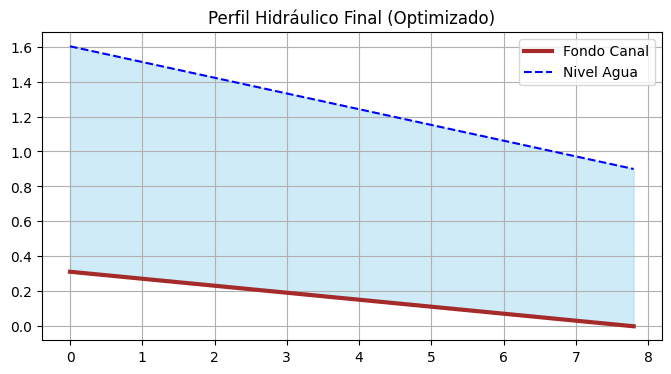

In [ ]:
import math
import matplotlib.pyplot as plt

# ==========================================================
# 1. ENTRADA DE DATOS DINÁMICA
# ==========================================================
print("--- SISTEMA DE DISEÑO Y OPTIMIZACIÓN DE BOCATOMAS ---")
print("1. Calcular Q (Tengo L y H)")
print("2. Calcular L (Tengo Q y H)")
print("3. Calcular H (Tengo Q y L)")
print("4. OPTIMIZACIÓN INVERSA: Definir Q de Entrega deseado")
opcion = input("Seleccione una opción: ")

# Parámetros fijos de la estructura
g, i, Lc, BL = 9.81, 0.04, 7.8, 0.15

if opcion == "4":
    Q_Te_objetivo = float(input("Ingrese el Caudal de Entrega deseado en el tanque (m3/s): "))
    diam_pulg = float(input("Diámetro del tubo de salida ecológica (pulgadas): "))

    # Iniciamos una búsqueda del Q_diseno necesario
    # Asumimos una aproximación inicial: Q_diseno debe ser un poco mayor al de entrega
    Q_diseno = Q_Te_objetivo + 0.05

    print("\n--- Buscando configuración óptima de rejilla (a y b) ---")
    # Valores estándar de búsqueda para optimizar
    a, b = 0.02, 0.0095 # Valores base para iniciar

    # Bucle de ajuste fino (Simulamos la optimización inversa)
    for _ in range(100):
        # Cálculos intermedios rápidos para ajustar el balance
        Vr_temp = 0.8  # Velocidad promedio estimada para el río
        Xs_temp = round((0.36 * math.pow(Vr_temp, 2/3)) + (0.60 * math.pow(0.20, 4/7)), 2)
        B_temp = Xs_temp + 0.10
        he_temp = math.pow((math.pow(Q_diseno, 2)) / (g * math.pow(B_temp, 2)), 1/3)
        Vc_temp = Q_diseno / (he_temp * B_temp)

        area_tubo = math.pi * math.pow((diam_pulg * 0.0254) / 2, 2)
        Q_eco_temp = area_tubo * Vc_temp
        Q_Te_actual = Q_diseno - Q_eco_temp

        if abs(Q_Te_actual - Q_Te_objetivo) < 0.001:
            break
        Q_diseno += (Q_Te_objetivo - Q_Te_actual) # Ajuste proporcional

    # Una vez hallado el Q_diseno necesario, pedimos L o H para completar Francis
    print(f"Para entregar {Q_Te_objetivo} m3/s, necesitamos captar {round(Q_diseno,3)} m3/s.")
    L = float(input("Defina Longitud de cresta L (m) para esta captación: "))
    H = round(math.pow(Q_diseno / (1.84 * L), 2/3), 2)

else:
    # Lógica normal de las opciones 1, 2 y 3
    if opcion == "1":
        L = float(input("Ingrese L (m): ")); H = float(input("Ingrese H (m): "))
        Q_diseno = round(1.84 * L * math.pow(H, 1.5), 2)
    elif opcion == "2":
        Q_diseno = float(input("Ingrese Q (m3/s): ")); H = float(input("Ingrese H (m): "))
        L = round(Q_diseno / (1.84 * math.pow(H, 1.5)), 2)
    elif opcion == "3":
        Q_diseno = float(input("Ingrese Q (m3/s): ")); L = float(input("Ingrese L (m): "))
        H = round(math.pow(Q_diseno / (1.84 * L), 2/3), 2)

    a = float(input("Ancho apertura rejilla 'a' (m): "))
    b = float(input("Ancho barra rejilla 'b' (m): "))
    diam_pulg = float(input("Diámetro tubo ecológico (pulg): "))

# ==========================================================
# 2. CÁLCULOS FINALES CRONOLÓGICOS (Basados en Q_diseno hallado)
# ==========================================================
Vr = round(Q_diseno / (L * H), 2)
Xs = round((0.36 * math.pow(Vr, 2/3)) + (0.60 * math.pow(H, 4/7)), 2)
B = round(Xs + 0.10, 2)
Aneta = round((a / (a + b)) * B * L, 2)
N = round(Aneta / (a * B), 2)
Vb = round(Q_diseno / (0.9 * Aneta), 2)

he = round(math.pow((math.pow(Q_diseno, 2)) / (g * math.pow(B, 2)), 1/3), 2)
t1, t2 = 2 * math.pow(he, 2), math.pow(he - (i * Lc / 3), 2)
h0 = round(math.pow(t1 + t2, 0.5) - (2/3 * i * Lc), 2)
Vc = round(Q_diseno / (he * B), 2)

area_tubo = round(math.pi * math.pow((diam_pulg * 0.0254) / 2, 2), 4)
Q_eco = round(area_tubo * Vc, 4)
Q_Te = round(Q_diseno - Q_eco, 4)

H0_wall, He_wall = round(h0 + BL, 2), round(h0 + BL + (i * Lc), 2)

# ==========================================================
# 3. RESULTADOS Y GRÁFICOS
# ==========================================================
print("\n" + "="*60)
print(f"{'MEMORIA DE CÁLCULO OPTIMIZADA':^60}")
print("="*60)
resultados = [
    ("Caudal Captación (Q)", f"{Q_diseno} m3/s"),
    ("Carga necesaria (H)", f"{H} m"),
    ("Longitud cresta (L)", f"{L} m"),
    ("Ancho de base (B)", f"{B} m"),
    ("Velocidad de Salida (Vc)", f"{Vc} m/s"),
    ("CAUDAL ECOLÓGICO", f"{Q_eco} m3/s"),
    ("CAUDAL DE ENTREGA FINAL", f"{Q_Te} m3/s")
]
for concepto, valor in resultados:
    print(f"{concepto:<35} | {valor:<15}")
print("="*60)

# Gráfico de Perfil Hidráulico
plt.figure(figsize=(8, 4))
plt.plot([0, Lc], [i*Lc, 0], 'brown', lw=3, label='Fondo Canal')
plt.plot([0, Lc], [i*Lc + h0, he], 'b--', label='Nivel Agua')
plt.fill_between([0, Lc], [i*Lc, 0], [i*Lc + h0, he], color='skyblue', alpha=0.4)
plt.title("Perfil Hidráulico Final (Optimizado)")
plt.legend(); plt.grid(True); plt.show()